In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import FeatureUnion

In [4]:
DATA_PATH = "./listings.csv"

df = pd.read_csv(DATA_PATH, encoding="utf-8")

# Supprimer les lignes dont les labels sonts vides
df = df[df['host_is_superhost'].isin(['t', 'f'])]
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2719440,https://www.airbnb.com/rooms/2719440,20250912034503,2025-09-12,previous scrape,Nice flat close to Montparnasse,This beautiful apartment is very well located ...,"The neighborhood is very nice, feel free to sh...",https://a0.muscache.com/pictures/295786e7-116c...,13915159,...,4.94,4.86,4.73,7510702406383,f,1,1,0,0,0.57
1,2721397,https://www.airbnb.com/rooms/2721397,20250912034503,2025-09-12,previous scrape,"Marais - Charming loft, river view","In the heart of historical Paris le Marais, gr...",Le Marais is the heart of Paris. Few years ago...,https://a0.muscache.com/pictures/de55313f-9b4b...,13925876,...,4.95,4.91,4.85,7510400455677,f,1,1,0,0,0.66
2,2726092,https://www.airbnb.com/rooms/2726092,20250912034503,2025-09-12,previous scrape,Superbe 2 pièces idéalement placé,A stone's throw from Parc Monceau and the Arc ...,Quiet and residential area... Close to the Bat...,https://a0.muscache.com/pictures/6d6c4bc6-9473...,13612373,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
3,2726327,https://www.airbnb.com/rooms/2726327,20250912034503,2025-09-12,previous scrape,"Cozy place, Sacré Coeur Montmartre in the SoPi",Cozy apartment close to everything.<br />Perfe...,One of the most trendy corners of the capital ...,https://a0.muscache.com/pictures/6b569382-aed7...,7483725,...,4.97,4.92,4.67,7510901014972,f,1,1,0,0,0.72
4,2727929,https://www.airbnb.com/rooms/2727929,20250912034503,2025-09-12,previous scrape,Appartement d'architecte - Montmartre,"Our apartment, refurbished by an architect in ...",The apartment is in the heart of Paris's 18th ...,https://a0.muscache.com/pictures/miso/Hosting-...,13960346,...,5.00,4.57,5.00,7511808333770,f,1,1,0,0,0.25


## Extraction des caractéristiques

In [5]:
text_cols = [
    # --- Modalité textuel ---
    'name',
    'description',
    'neighborhood_overview',
    'host_about'
]

num_cols = [
    # --- Modalité numérique ---
    'host_response_rate',
    'host_acceptance_rate',
    'host_listings_count',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
]

cat_cols = [
    # --- Modalité catégorielles ---
    'host_response_time',
    'host_identity_verified',
    'room_type',
    'instant_bookable',
]

target_col = ['host_is_superhost']

df = pd.concat([df[text_cols], df[num_cols], df[cat_cols], df[target_col]], axis=1)
df

,name,description,neighborhood_overview,host_about,host_response_rate,host_acceptance_rate,host_listings_count,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,host_response_time,host_identity_verified,room_type,instant_bookable,host_is_superhost
0,Nice flat close to Montparnasse,This beautiful apartment is very well located ...,"The neighborhood is very nice, feel free to sh...","I am living in Paris since 10 years, and I lov...",NaN,NaN,1.0,79,0.57,4.78,4.60,4.94,4.86,4.73,NaN,t,Entire home/apt,f,f
1,"Marais - Charming loft, river view","In the heart of historical Paris le Marais, gr...",Le Marais is the heart of Paris. Few years ago...,"I travel a lot for work and when I'm away, my ...",100%,92%,1.0,88,0.66,4.86,4.77,4.95,4.91,4.85,within a few hours,t,Entire home/apt,f,t
2,Superbe 2 pièces idéalement placé,A stone's throw from Parc Monceau and the Arc ...,Quiet and residential area... Close to the Bat...,NaN,NaN,NaN,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,Entire home/apt,f,f
3,"Cozy place, Sacré Coeur Montmartre in the SoPi",Cozy apartment close to everything.<br />Perfe...,One of the most trendy corners of the capital ...,"Jeune ingénieur, je propose mon appartement à ...",100%,89%,1.0,99,0.72,4.81,4.82,4.97,4.92,4.67,within an hour,t,Entire home/apt,f,f
4,Appartement d'architecte - Montmartre,"Our apartment, refurbished by an architect in ...",The apartment is in the heart of Paris's 18th ...,NaN,100%,100%,1.0,7,0.25,5.00,5.00,5.00,4.57,5.00,within an hour,t,Entire home/apt,f,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81847,"BM-Cocon citadin, quartier du faubourg Saint D...",The Konciergerie is delighted to offer you thi...,NaN,"Bienvenue à Paris ! \nJe suis Eliav, passionné...",100%,100%,105.0,1,1.00,5.00,4.00,4.00,5.00,3.00,within an hour,t,Entire home/apt,t,f
81848,Apt a/c 1BR/2P - Saint-Lazare/Les Champs Elysée,📌 Checkmyguest offers you a charming and spaci...,🏘️ The 8th arrondissement of Paris is one of t...,Checkmyguest est une entreprise de gestion loc...,100%,100%,249.0,2,2.00,5.00,5.00,5.00,5.00,5.00,within an hour,t,Entire home/apt,t,t
81849,Superbe duplex avec terrasse face Tour Eiffel,The Konciergerie is proud to present this char...,NaN,"Bienvenue à Paris ! \nJe suis Eliav, passionné...",100%,100%,105.0,0,NaN,NaN,NaN,NaN,NaN,NaN,within an hour,t,Entire home/apt,t,f
81851,Appt entier 35m2 proche Montmartre,Quiet 35 m2 apartment in the heart of Paris.<b...,NaN,"Mon appartement parisien est très cosy, décoré...",100%,74%,2.0,0,NaN,NaN,NaN,NaN,NaN,NaN,within an hour,t,Private room,f,t


## Exploration des données

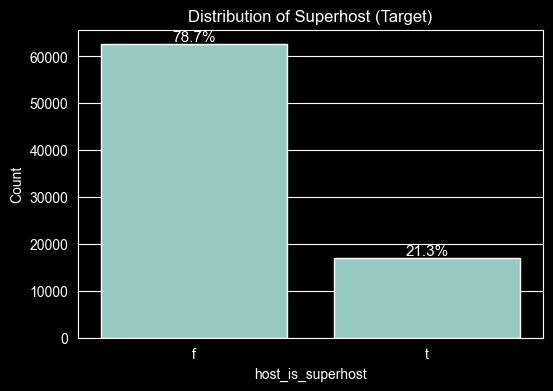

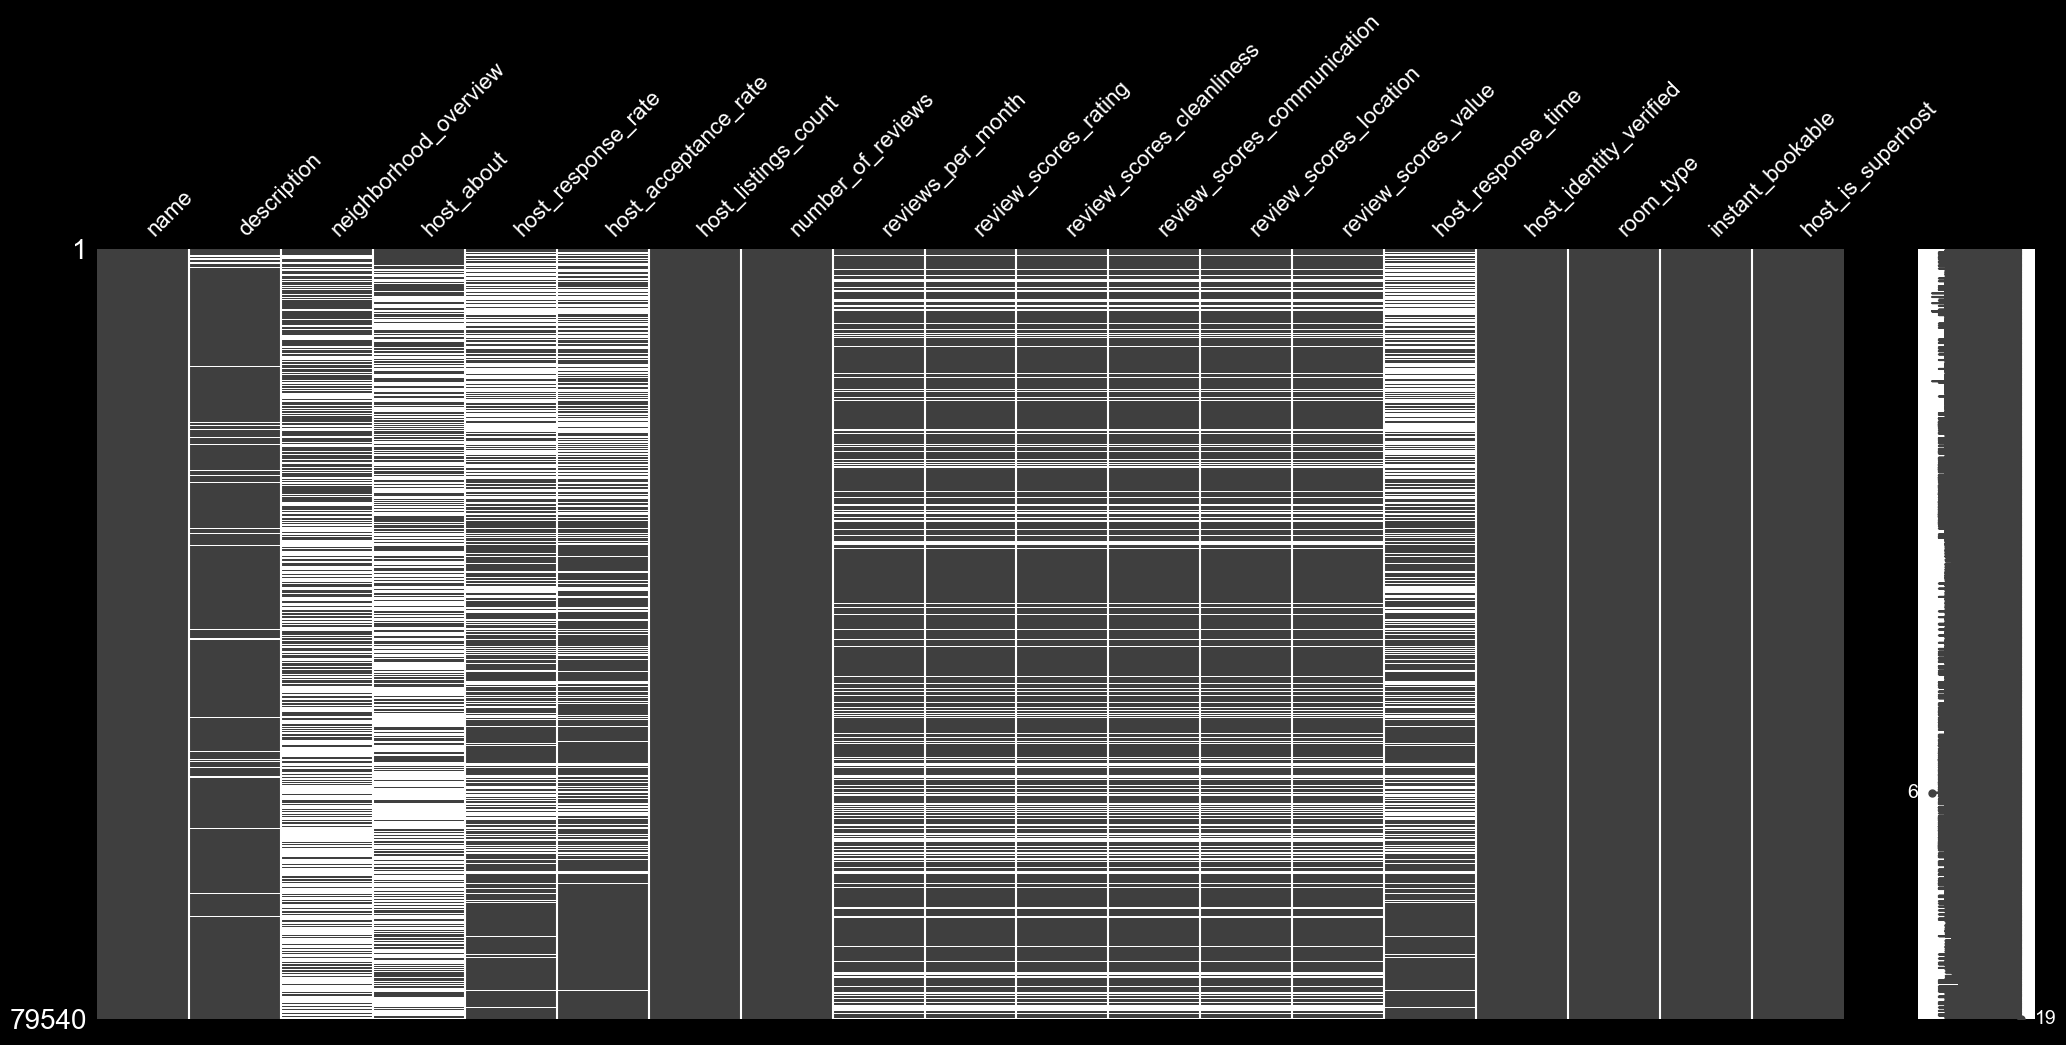

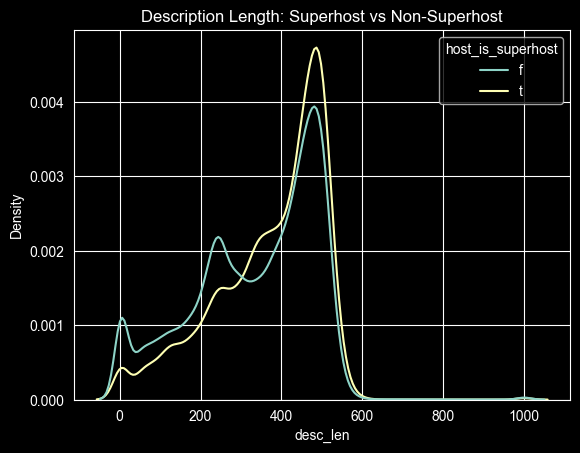

       host_listings_count  number_of_reviews  reviews_per_month  \
count         79520.000000       79540.000000       61903.000000   
mean             28.958677          27.210058           1.015106   
std             114.733337          62.226657           1.328686   
min               0.000000           0.000000           0.010000   
25%               1.000000           1.000000           0.170000   
50%               1.000000           7.000000           0.550000   
75%               3.000000          28.000000           1.360000   
max            8301.000000        4040.000000          67.920000   

       review_scores_rating  review_scores_cleanliness  \
count          61903.000000               61895.000000   
mean               4.736451                   4.668646   
std                0.384292                   0.438144   
min                0.000000                   0.000000   
25%                4.650000                   4.540000   
50%                4.840000            

In [6]:
# analyse de la distribution de la variable cible
plt.figure(figsize=(6,4))
ax = sns.countplot(x='host_is_superhost', data=df)

# calcul des pourcentages des classes
total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., count),
                ha='center',
                va='bottom',
                fontsize=11)

plt.title("Distribution of Superhost (Target)")
plt.ylabel("Count")
plt.show()

# analyse des données manquantes
msno.matrix(df)
plt.show()

# exploration des données textuelles (longueur des descriptions, vocabulaire, exemples)
df['desc_len'] = df['description'].astype(str).apply(len)
sns.kdeplot(data=df, x='desc_len', hue='host_is_superhost', common_norm=False)
plt.title("Description Length: Superhost vs Non-Superhost")
plt.show()

df.drop('desc_len', axis=1, inplace=True)

# statistiques descriptives des variables tabulaires
print(df[num_cols].describe())
print(df[cat_cols].describe())

### Analyse synthétique des variables numériques
Les statistiques descriptives révèlent une forte disparité entre les variables numériques.

Les variables liées à l’activité des hôtes (host_listings_count, number_of_reviews, reviews_per_month) présentent des distributions fortement asymétriques, avec des médianes faibles mais des valeurs maximales très élevées, indiquant la présence de quelques hôtes ou logements particulièrement actifs.

À l’inverse, les variables de scores d’évaluation affichent des moyennes élevées et une faible dispersion, traduisant une concentration des notes vers les valeurs hautes, phénomène classique dans les systèmes d’évaluation en ligne.
La présence de valeurs minimales nulles suggère toutefois la nécessité d’un traitement spécifique des données manquantes avant la modélisation.

### Analyse synthétique des variables qualitatives
Les variables qualitatives mettent en évidence des comportements majoritaires bien définis.
La plupart des hôtes répondent rapidement aux demandes, la modalité « within an hour » étant la plus fréquente parmi les valeurs observées.
Une large majorité des hôtes ont une identité vérifiée (host_identity_verified = true), ce qui suggère un haut niveau de conformité aux exigences de la plateforme.

Concernant le type de logement, les annonces de type « Entire home/apt » dominent largement le jeu de données, tandis que les options de réservation instantanée sont moins répandues, avec une majorité de logements non instantanément réservables.

### Analyse de longueur des descriptions pour les 2 classes
La distribution de la longueur des descriptions met en évidence une tendance claire : les hôtes Superhost présentent une densité plus élevée pour des descriptions plus longues, tandis que les Non-Superhosts sont davantage représentés parmi les descriptions plus courtes.

## Gestion des données manquantes et encodage

In [7]:
# ============= Types textuels =============
def tr_name(x):
    return x if pd.notnull(x) else ''

def tr_description(x):
    return x if pd.notnull(x) else ''

def tr_neighborhood_overview(x):
    return x if pd.notnull(x) else ''

def tr_host_about(x):
    return x if pd.notnull(x) else ''

# ============= Types numériques =============
def tr_host_response_rate(x):
    return float(str(x).strip('%')) / 100 if pd.notnull(x) else 0

def tr_host_acceptance_rate(x):
    return float(str(x).strip('%')) / 100 if pd.notnull(x) else 0

def tr_host_listings_count(x):
    return x if pd.notnull(x) else 0

def tr_number_of_reviews(x):
    return x if pd.notnull(x) else 0

def tr_reviews_per_month(x):
    return x if pd.notnull(x) else 0

def tr_review_scores_rating(x):
    return x if pd.notnull(x) else 0

def tr_review_scores_cleanliness(x):
    return x if pd.notnull(x) else 0

def tr_review_scores_communication(x):
    return x if pd.notnull(x) else 0

def tr_review_scores_location(x):
    return x if pd.notnull(x) else 0

def tr_review_scores_value(x):
    return x if pd.notnull(x) else 0

# ============= Types catégorielles =============
def tr_host_response_time(x):
    mapping = {
        'within an hour': 0,
        'within a few hours': 1,
        'within a day': 2,
        'a few days or more': 3
    }
    return mapping.get(x, 4)

def tr_host_identity_verified(x):
    mapping = {
        'f': 0,
        't': 1
    }
    return mapping.get(x, 2)


def tr_room_type(x):
    mapping = {
        'Entire home/apt': 0,
        'Private room': 1,
        'Hotel room': 2,
        'Shared room': 3
    }
    return mapping.get(x, 4)

def tr_instant_bookable(x):
    mapping = {
        'f': 0,
        't': 1
    }
    return mapping.get(x, 2)

def tr_host_is_superhost(x):
    mapping = {
        'f': 0,
        't': 1
    }
    return mapping.get(x, 2)

tr_mapping = {
    'name': tr_name,
    'description': tr_description,
    'neighborhood_overview': tr_neighborhood_overview,
    'host_about': tr_host_about,

    'host_response_rate': tr_host_response_rate,
    'host_acceptance_rate': tr_host_acceptance_rate,
    'host_listings_count': tr_host_listings_count,
    'number_of_reviews': tr_number_of_reviews,
    'reviews_per_month': tr_reviews_per_month,
    'review_scores_rating': tr_review_scores_rating,
    'review_scores_cleanliness': tr_review_scores_cleanliness,
    'review_scores_communication': tr_review_scores_communication,
    'review_scores_location': tr_review_scores_location,
    'review_scores_value': tr_review_scores_value,

    'host_response_time': tr_host_response_time,
    'host_identity_verified': tr_host_identity_verified,
    'room_type': tr_room_type,
    'instant_bookable': tr_instant_bookable,

    'host_is_superhost': tr_host_is_superhost,
}

for col in df.columns:
    df[col] = df[col].apply(tr_mapping[col])

df.head()

,name,description,neighborhood_overview,host_about,host_response_rate,host_acceptance_rate,host_listings_count,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,host_response_time,host_identity_verified,room_type,instant_bookable,host_is_superhost
0,Nice flat close to Montparnasse,This beautiful apartment is very well located ...,"The neighborhood is very nice, feel free to sh...","I am living in Paris since 10 years, and I lov...",0.0,0.00,1.0,79,0.57,4.78,4.60,4.94,4.86,4.73,4,1,0,0,0
1,"Marais - Charming loft, river view","In the heart of historical Paris le Marais, gr...",Le Marais is the heart of Paris. Few years ago...,"I travel a lot for work and when I'm away, my ...",1.0,0.92,1.0,88,0.66,4.86,4.77,4.95,4.91,4.85,1,1,0,0,1
2,Superbe 2 pièces idéalement placé,A stone's throw from Parc Monceau and the Arc ...,Quiet and residential area... Close to the Bat...,,0.0,0.00,1.0,0,0.00,0.00,0.00,0.00,0.00,0.00,4,0,0,0,0
3,"Cozy place, Sacré Coeur Montmartre in the SoPi",Cozy apartment close to everything.<br />Perfe...,One of the most trendy corners of the capital ...,"Jeune ingénieur, je propose mon appartement à ...",1.0,0.89,1.0,99,0.72,4.81,4.82,4.97,4.92,4.67,0,1,0,0,0
4,Appartement d'architecte - Montmartre,"Our apartment, refurbished by an architect in ...",The apartment is in the heart of Paris's 18th ...,,1.0,1.00,1.0,7,0.25,5.00,5.00,5.00,4.57,5.00,0,1,0,0,0


In [8]:
# Fonction pour déssiner la courbe ROC
def plot_roc(y_true, pred_probs):
    fpr, tpr, thresholds = roc_curve(y_true, pred_probs)

    roc_auc = roc_auc_score(y_true, pred_probs)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Modèle 1: Régression Logistique

In [9]:
# Concaténer tous les features textuels
X_text = df[text_cols].agg(' '.join, axis=1)

# Les données tabulaires
X_tab = df[num_cols + cat_cols]

# Deux types de données concaténé
X_all = pd.concat([X_tab, X_text.to_frame(name='full_text')], axis=1)

# Labels
labels = df['host_is_superhost'].astype(int)

print(f"Forme de jeu de donnée text: {X_text.shape}")
print(f"Forme de jeu de donnée tableau: {X_tab.shape}")
print(f"Forme de jeu de donnée combiné: {X_all.shape}")
print(f"Forme de label: {labels.shape}")

Forme de jeu de donnée text: (79540,)
Forme de jeu de donnée tableau: (79540, 14)
Forme de jeu de donnée combiné: (79540, 15)
Forme de label: (79540,)


### Classification selon les données textuelles (LR)

In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, labels, test_size=0.2, random_state=42, stratify=labels
)

text_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),  # utilise 1 et 2 gram
        min_df=2,
        max_features=20000  # longueur des features (les mots comme features)
    )),
    ("lr", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",  # donner un poid pour chaque classe
        n_jobs=-1
    ))
])

print("Structure de classifieur de text")
text_clf

Structure de classifieur de text


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=2,
                                 ngram_range=(1, 2))),
                ('lr',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    n_jobs=-1))])

              precision    recall  f1-score   support

           0      0.889     0.770     0.825     12514
           1      0.432     0.645     0.517      3394

    accuracy                          0.743     15908
   macro avg      0.660     0.707     0.671     15908
weighted avg      0.791     0.743     0.760     15908



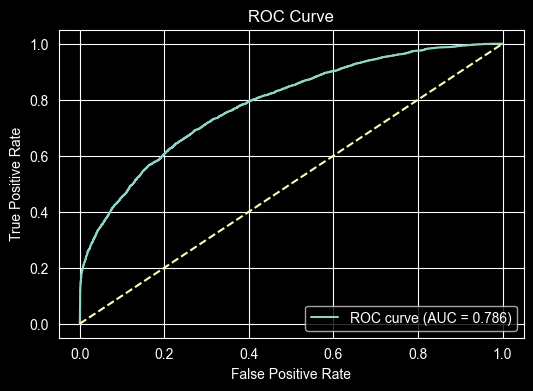

In [11]:
# entrainement et prédiction
text_clf.fit(X_train_text, y_train)
pred = text_clf.predict(X_test_text)
pred_probs = text_clf.predict_proba(X_test_text)[:, 1]

print(classification_report(y_test, pred, digits=3))
plot_roc(y_test, pred_probs)

### Classification selon les données tabulaires (LR)

In [12]:
X_train_tab, X_test_tab, y_train, y_test = train_test_split(
    X_tab, labels, test_size=0.2, random_state=42, stratify=labels
)

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())  # Normaliser les données quantitatives
])

cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # transformer les données catégorielles en one hot
])

preprocessor = ColumnTransformer(
    # Pour chaque type de donnée, adapter les transformer correspondants
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

# Classifieur pour les données tabulaires (quantitatives + qualitatives(catégorielles))
tab_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    ))
])

print("Structure de classifieur des données tabulaires:")
tab_clf

Structure de classifieur des données tabulaires:


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['host_response_rate',
                                                   'host_acceptance_rate',
                                                   'host_listings_count',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'review_scores_rating',
                                                   'review_scores_cleanliness',
                                                   'review_scores_communication',
                                                   'review_scores_location',
                                                   'review_scores_value']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['host_response_time',
                                                   'host_identity_verified',
                                                   'room_type',
                                                   'instant_bookable'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    n_jobs=-1, random_state=42))])

              precision    recall  f1-score   support

           0      0.948     0.705     0.809     12514
           1      0.441     0.856     0.582      3394

    accuracy                          0.737     15908
   macro avg      0.694     0.781     0.695     15908
weighted avg      0.839     0.737     0.760     15908



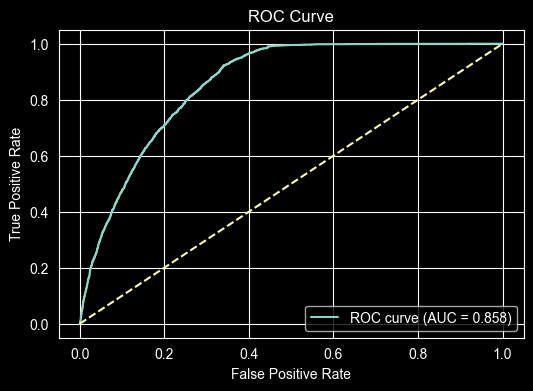

In [13]:
tab_clf.fit(X_train_tab, y_train)
y_pred = tab_clf.predict(X_test_tab)
pred_probs = tab_clf.predict_proba(X_test_tab)[:, 1]

print(classification_report(y_test, y_pred, digits=3))
plot_roc(y_test, pred_probs)

### Classification selon les deux modalités (LR)

- Early fusion (LR)

In [14]:
X_train_comb, X_test_comb, y_train, y_test = train_test_split(X_all, labels, test_size=0.2, random_state=42, stratify=labels)


# réduction de dimension des texts, sinon la grande dimension text va diluer les features tabulaires: 20000 -> 128
text_pca = Pipeline([
    ('selector', ColumnTransformer([
        ('text_select', TfidfVectorizer(ngram_range=(1,2), max_features=20000), 'full_text')
    ])),
    ('svd', TruncatedSVD(n_components=128, random_state=42))
])

# Early fusion des features
processing_union = FeatureUnion([
    ('text_features', text_pca),
    ('tab_features', preprocessor)
])

# Modèle 1: régression logistique
comb_clf = Pipeline([
    ('union', processing_union),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    ))
])

print("Structure de classifieur des données combiné:")
comb_clf


Structure de classifieur des données combiné:


Pipeline(steps=[('union',
                 FeatureUnion(transformer_list=[('text_features',
                                                 Pipeline(steps=[('selector',
                                                                  ColumnTransformer(transformers=[('text_select',
                                                                                                   TfidfVectorizer(max_features=20000,
                                                                                                                   ngram_range=(1,
                                                                                                                                2)),
                                                                                                   'full_text')])),
                                                                 ('svd',
                                                                  TruncatedSVD(n_components=128,
                                                                               random_state=42))])),
                                                ('tab_features',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  Pipeline(steps=[('s...
                                                                                   'review_scores_cleanliness',
                                                                                   'review_scores_communication',
                                                                                   'review_scores_location',
                                                                                   'review_scores_value']),
                                                                                 ('cat',
                                                                                  Pipeline(steps=[('onehot',
                                                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                                                  ['host_response_time',
                                                                                   'host_identity_verified',
                                                                                   'room_type',
                                                                                   'instant_bookable'])]))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    n_jobs=-1, random_state=42))])

              precision    recall  f1-score   support

           0      0.954     0.742     0.835     12514
           1      0.477     0.867     0.616      3394

    accuracy                          0.769     15908
   macro avg      0.715     0.805     0.725     15908
weighted avg      0.852     0.769     0.788     15908



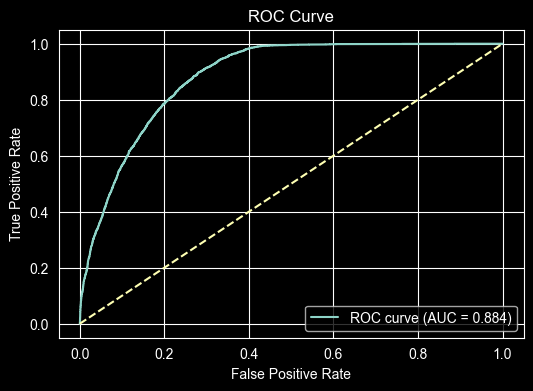

In [15]:
comb_clf.fit(X_train_comb, y_train)
y_pred = comb_clf.predict(X_test_comb)
pred_probs = comb_clf.predict_proba(X_test_comb)[:, 1]

print(classification_report(y_test, y_pred, digits=3))
plot_roc(y_test, pred_probs)

- Late fusion (LR)

--- Late Fusion (Meta LR Classifier) Result ---
              precision    recall  f1-score   support

           0      0.933     0.834     0.881     12514
           1      0.560     0.778     0.651      3394

    accuracy                          0.822     15908
   macro avg      0.746     0.806     0.766     15908
weighted avg      0.853     0.822     0.832     15908



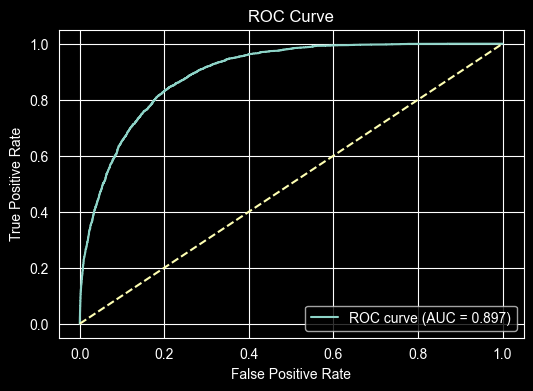

In [16]:
train_prob_text = text_clf.predict_proba(X_train_text)[:, 1].reshape(-1, 1)
train_prob_tab = tab_clf.predict_proba(X_train_tab)[:, 1].reshape(-1, 1)

# concaténer les probabilité de classe 1 (is superhost) pour les deux modalité
meta_X_train = np.hstack([train_prob_text, train_prob_tab])  # (n, 2)

# entrainement de Meta-Classifier / Gating Model
# 2 poids du modèle - 2 poids des deux classifieurs (expert textuel et expert tabulaire)
meta_clf = LogisticRegression(class_weight='balanced')
meta_clf.fit(meta_X_train, y_train)

# évaluation
test_prob_text = text_clf.predict_proba(X_test_text)[:, 1].reshape(-1, 1)
test_prob_tab = tab_clf.predict_proba(X_test_tab)[:, 1].reshape(-1, 1)
meta_X_test = np.hstack([test_prob_text, test_prob_tab])

final_pred_meta = meta_clf.predict(meta_X_test)
pred_probs = meta_clf.predict_proba(meta_X_test)[:, 1]

print("--- Late Fusion (Meta LR Classifier) Result ---")
print(classification_report(y_test, final_pred_meta, digits=3))
plot_roc(y_test, pred_probs)

# Modèle 2: MoE (Mélange des Experts)

In [17]:
class MoEPredictor(nn.Module):
    def __init__(self, input_dim, num_experts=6):
        super(MoEPredictor, self).__init__()
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(input_dim, 64),
                nn.ReLU(),
                nn.Dropout(),
                nn.Linear(64, 1)
            ) for _ in range(num_experts)
        ])

        self.gate = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, num_experts),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        weights = self.gate(x)  # (n, num_experts), poid de chaque expert

        expert_outputs = torch.cat([exp(x) for exp in self.experts], dim=1)  # (n, num_experts), output de chaque expert

        # Output = Σ (weight_i * expert_i)
        final_output = torch.sum(weights * expert_outputs, dim=1, keepdim=True)  # (n, 1)
        return torch.sigmoid(final_output)


In [18]:
def train_moe(X_train, X_test, y_train, y_test, num_experts, num_epochs):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # weight = negative_samples / positive_samples = 78.7 / 21.3 = 3.7
    pos_weight = torch.tensor([3.7]).to(device)
    input_dim = X_train.shape[1]

    moe_model = MoEPredictor(input_dim=input_dim, num_experts=num_experts).to(device)

    history = {'train_loss': [], 'test_f1': [], 'test_auc': []}

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(moe_model.parameters(), lr=0.001)

    # entrainement
    for epoch in range(num_epochs):
        moe_model.train()
        optimizer.zero_grad()
        outputs = moe_model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        moe_model.eval()
        with torch.no_grad():
            test_outputs = moe_model(X_test)
            # seuil = 0.5 (utilisé sigmoid)
            test_preds = (test_outputs > 0.5).float()

            y_true = y_test.numpy()
            y_pred = test_preds.cpu().numpy()
            y_prob = test_outputs.cpu().numpy()

            # calcul de f-mesure et AUC
            current_f1 = f1_score(y_true, y_pred, average='macro')
            current_auc = roc_auc_score(y_true, y_prob)

            # sauvegarder les log
            history['train_loss'].append(loss.item())
            history['test_f1'].append(current_f1)
            history['test_auc'].append(current_auc)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {loss.item():.4f} | Test F1: {current_f1:.4f} | Test AUC: {current_auc:.4f}")

    # rapport final
    print("\n--- Final Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=['Not Superhost', 'Superhost'], digits=3))
    plot_roc(y_true, y_prob)

    return moe_model

### Classification selon les données textuelles (MoE)

Forme de jeu de donnée train: torch.Size([63632, 128])
Forme de jeu de donnée test: torch.Size([15908, 128])
Epoch [10/500] - Loss: 1.1396 | Test F1: 0.5231 | Test AUC: 0.6453
Epoch [20/500] - Loss: 1.1364 | Test F1: 0.4773 | Test AUC: 0.6579
Epoch [30/500] - Loss: 1.1328 | Test F1: 0.4593 | Test AUC: 0.6619
Epoch [40/500] - Loss: 1.1284 | Test F1: 0.4599 | Test AUC: 0.6640
Epoch [50/500] - Loss: 1.1232 | Test F1: 0.4677 | Test AUC: 0.6651
Epoch [60/500] - Loss: 1.1172 | Test F1: 0.4770 | Test AUC: 0.6654
Epoch [70/500] - Loss: 1.1105 | Test F1: 0.4876 | Test AUC: 0.6655
Epoch [80/500] - Loss: 1.1037 | Test F1: 0.4926 | Test AUC: 0.6655
Epoch [90/500] - Loss: 1.0971 | Test F1: 0.4979 | Test AUC: 0.6659
Epoch [100/500] - Loss: 1.0912 | Test F1: 0.5026 | Test AUC: 0.6665
Epoch [110/500] - Loss: 1.0857 | Test F1: 0.5045 | Test AUC: 0.6676
Epoch [120/500] - Loss: 1.0808 | Test F1: 0.5119 | Test AUC: 0.6691
Epoch [130/500] - Loss: 1.0766 | Test F1: 0.5175 | Test AUC: 0.6709
Epoch [140/500] 

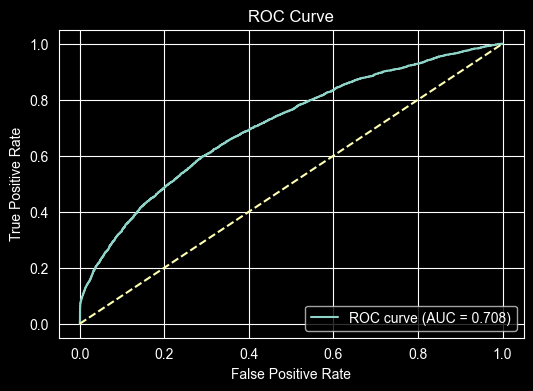

In [19]:
X_text_df = X_text.to_frame(name='full_text')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text_df, labels, test_size=0.2, random_state=42, stratify=labels
)

# utilise le pipeline tf-idf et pca défini précédement pour transformer les textes en vecteurs
X_train_text = torch.tensor(text_pca.fit_transform(X_train_text).astype(np.float32)).to(device)  # (n, 128)
X_test_text = torch.tensor(text_pca.transform(X_test_text).astype(np.float32)).to(device)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)  # (n, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(f"Forme de jeu de donnée train: {X_train_text.shape}")
print(f"Forme de jeu de donnée test: {X_test_text.shape}")

text_moe = train_moe(X_train_text, X_test_text, y_train, y_test, num_experts=6, num_epochs=500)

### Classification selon les données tabulaires (MoE)

Forme de jeu de donnée train: torch.Size([63632, 24])
Forme de jeu de donnée test: torch.Size([15908, 24])
Epoch [10/500] - Loss: 1.1197 | Test F1: 0.6884 | Test AUC: 0.8253
Epoch [20/500] - Loss: 1.0945 | Test F1: 0.7004 | Test AUC: 0.8270
Epoch [30/500] - Loss: 1.0710 | Test F1: 0.7006 | Test AUC: 0.8272
Epoch [40/500] - Loss: 1.0494 | Test F1: 0.6973 | Test AUC: 0.8276
Epoch [50/500] - Loss: 1.0306 | Test F1: 0.6956 | Test AUC: 0.8284
Epoch [60/500] - Loss: 1.0141 | Test F1: 0.6922 | Test AUC: 0.8295
Epoch [70/500] - Loss: 1.0015 | Test F1: 0.6910 | Test AUC: 0.8307
Epoch [80/500] - Loss: 0.9931 | Test F1: 0.6934 | Test AUC: 0.8317
Epoch [90/500] - Loss: 0.9869 | Test F1: 0.6987 | Test AUC: 0.8334
Epoch [100/500] - Loss: 0.9820 | Test F1: 0.7020 | Test AUC: 0.8357
Epoch [110/500] - Loss: 0.9779 | Test F1: 0.7055 | Test AUC: 0.8386
Epoch [120/500] - Loss: 0.9748 | Test F1: 0.7105 | Test AUC: 0.8418
Epoch [130/500] - Loss: 0.9727 | Test F1: 0.7135 | Test AUC: 0.8450
Epoch [140/500] - 

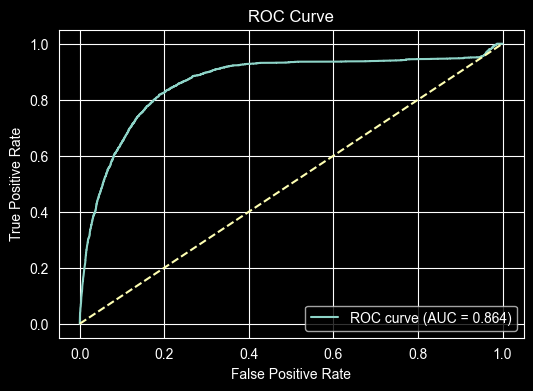

In [20]:
X_train_tab, X_test_tab, y_train, y_test = train_test_split(
    X_tab, labels, test_size=0.2, random_state=42, stratify=labels
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# utilise le preprocesseur de donnée tabulaire
X_train_tab = torch.tensor(preprocessor.fit_transform(X_train_tab).astype(np.float32)).to(device)  # (n, 24)
X_test_tab = torch.tensor(preprocessor.transform(X_test_tab).astype(np.float32)).to(device)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)  # (n, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(f"Forme de jeu de donnée train: {X_train_tab.shape}")
print(f"Forme de jeu de donnée test: {X_test_tab.shape}")

tab_moe = train_moe(X_train_tab, X_test_tab, y_train, y_test, num_experts=6,num_epochs=500)

### Classification selon les deux modalités (MoE)

- Early fusion (MoE)

Forme de jeu de donnée train: torch.Size([63632, 152])
Forme de jeu de donnée test: torch.Size([15908, 152])
Epoch [10/500] - Loss: 1.1209 | Test F1: 0.7158 | Test AUC: 0.8372
Epoch [20/500] - Loss: 1.0988 | Test F1: 0.7045 | Test AUC: 0.8380
Epoch [30/500] - Loss: 1.0747 | Test F1: 0.6976 | Test AUC: 0.8384
Epoch [40/500] - Loss: 1.0497 | Test F1: 0.6942 | Test AUC: 0.8390
Epoch [50/500] - Loss: 1.0266 | Test F1: 0.6937 | Test AUC: 0.8401
Epoch [60/500] - Loss: 1.0072 | Test F1: 0.6959 | Test AUC: 0.8416
Epoch [70/500] - Loss: 0.9922 | Test F1: 0.7020 | Test AUC: 0.8433
Epoch [80/500] - Loss: 0.9813 | Test F1: 0.7142 | Test AUC: 0.8495
Epoch [90/500] - Loss: 0.9733 | Test F1: 0.7221 | Test AUC: 0.8579
Epoch [100/500] - Loss: 0.9667 | Test F1: 0.7288 | Test AUC: 0.8633
Epoch [110/500] - Loss: 0.9616 | Test F1: 0.7353 | Test AUC: 0.8678
Epoch [120/500] - Loss: 0.9574 | Test F1: 0.7418 | Test AUC: 0.8721
Epoch [130/500] - Loss: 0.9535 | Test F1: 0.7460 | Test AUC: 0.8761
Epoch [140/500] 

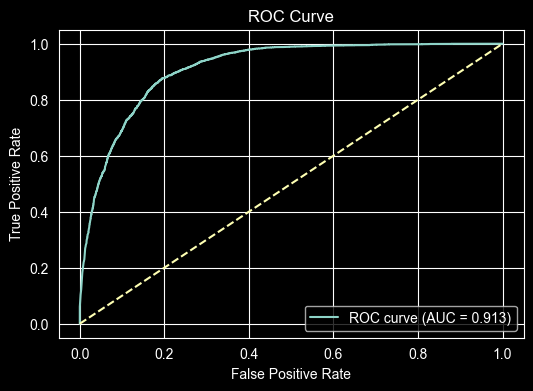

In [21]:
X_train_comb, X_test_comb, y_train, y_test = train_test_split(X_all, labels, test_size=0.2, random_state=42, stratify=labels)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# transforme les features combinés en tensor
X_train_combined = torch.tensor(processing_union.fit_transform(X_train_comb).astype(np.float32)).to(device)  # (n, input_dim)
X_test_combined = torch.tensor(processing_union.transform(X_test_comb).astype(np.float32)).to(device)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)  # (n, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(f"Forme de jeu de donnée train: {X_train_combined.shape}")
print(f"Forme de jeu de donnée test: {X_test_combined.shape}")

early_fusion_moe = train_moe(X_train_combined, X_test_combined, y_train, y_test, num_experts=6, num_epochs=500)

- Late fusion (MoE)

Forme de jeu de donnée train: torch.Size([63632, 2])
Forme de jeu de donnée test: torch.Size([15908, 2])
Epoch [10/500] - Loss: 1.1336 | Test F1: 0.7702 | Test AUC: 0.8806
Epoch [20/500] - Loss: 1.1227 | Test F1: 0.7771 | Test AUC: 0.8799
Epoch [30/500] - Loss: 1.1115 | Test F1: 0.7797 | Test AUC: 0.8794
Epoch [40/500] - Loss: 1.1002 | Test F1: 0.7801 | Test AUC: 0.8792
Epoch [50/500] - Loss: 1.0883 | Test F1: 0.7803 | Test AUC: 0.8792
Epoch [60/500] - Loss: 1.0753 | Test F1: 0.7801 | Test AUC: 0.8792
Epoch [70/500] - Loss: 1.0613 | Test F1: 0.7792 | Test AUC: 0.8794
Epoch [80/500] - Loss: 1.0460 | Test F1: 0.7787 | Test AUC: 0.8796
Epoch [90/500] - Loss: 1.0300 | Test F1: 0.7782 | Test AUC: 0.8798
Epoch [100/500] - Loss: 1.0131 | Test F1: 0.7766 | Test AUC: 0.8800
Epoch [110/500] - Loss: 0.9978 | Test F1: 0.7771 | Test AUC: 0.8805
Epoch [120/500] - Loss: 0.9837 | Test F1: 0.7761 | Test AUC: 0.8810
Epoch [130/500] - Loss: 0.9720 | Test F1: 0.7757 | Test AUC: 0.8813
Epoch [140/500] - Lo

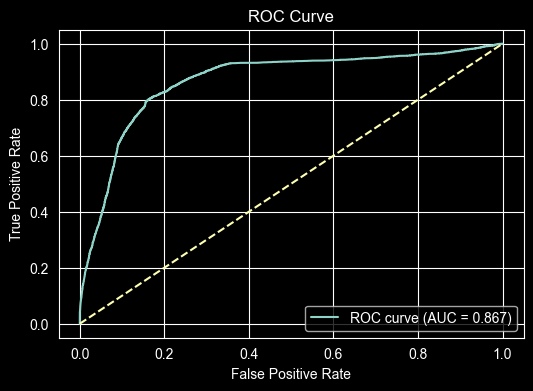

In [22]:
# prédiction des probabilité de text moe et tab moe en tant que jeu de l'entrainement pour late fusion moe
train_text_proba = text_moe(X_train_text).detach()
train_tab_proba = tab_moe(X_train_tab).detach()
test_text_proba = text_moe(X_test_text).detach()
test_tab_proba = tab_moe(X_test_tab).detach()

# concatène les deux probabilités
meta_X_train_moe = torch.hstack([train_text_proba, train_tab_proba]).to(device)  # (n, 2)
meta_X_test_moe = torch.hstack([test_text_proba, test_tab_proba]).to(device)

print(f"Forme de jeu de donnée train: {meta_X_train_moe.shape}")
print(f"Forme de jeu de donnée test: {meta_X_test_moe.shape}")

meta_moe = train_moe(meta_X_train_moe, meta_X_test_moe, y_train, y_test, num_experts=6, num_epochs=500)
